### **For this assignment the only permitted libraries to use are Numpy, Scipy, MatplotLib and Pandas! Use of generative AI is not allowed.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

## Data loading

In [79]:

# Load the data
train_data = np.load('train_data_2026.npy')
test_data = np.load('test_data_2026.npy')
val_data = np.load('val_data_2026.npy')

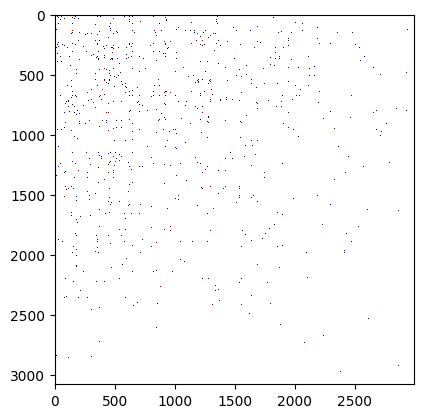

In [80]:
# Visualize the [user x user] arrays
cmap = cm.jet
cmap.set_bad('white',1.)

masked_array_train = np.ma.array(train_data, mask=np.isnan(train_data))
plt.imshow(masked_array_train, interpolation='nearest', cmap=cmap)
plt.pause(0.1)

## Familiarization

In [81]:
# Calculate sparsity
total_elements = train_data.size
non_nan = np.sum(~np.isnan(train_data))
sparsity = 1 - (non_nan / total_elements)
print(f"Overall Sparsity: {sparsity:.4%}")

# Label distribution
labels = train_data[~np.isnan(train_data)]
unique, counts = np.unique(labels, return_counts=True)
label_dist = dict(zip(unique, counts))
print(f"Label distribution: {label_dist}")
print(f"Ratio (1s/0s): {counts[1]/counts[0]:.2f}")

Overall Sparsity: 99.4348%
Label distribution: {np.float64(0.0): np.int64(42964), np.float64(1.0): np.int64(9158)}
Ratio (1s/0s): 0.21


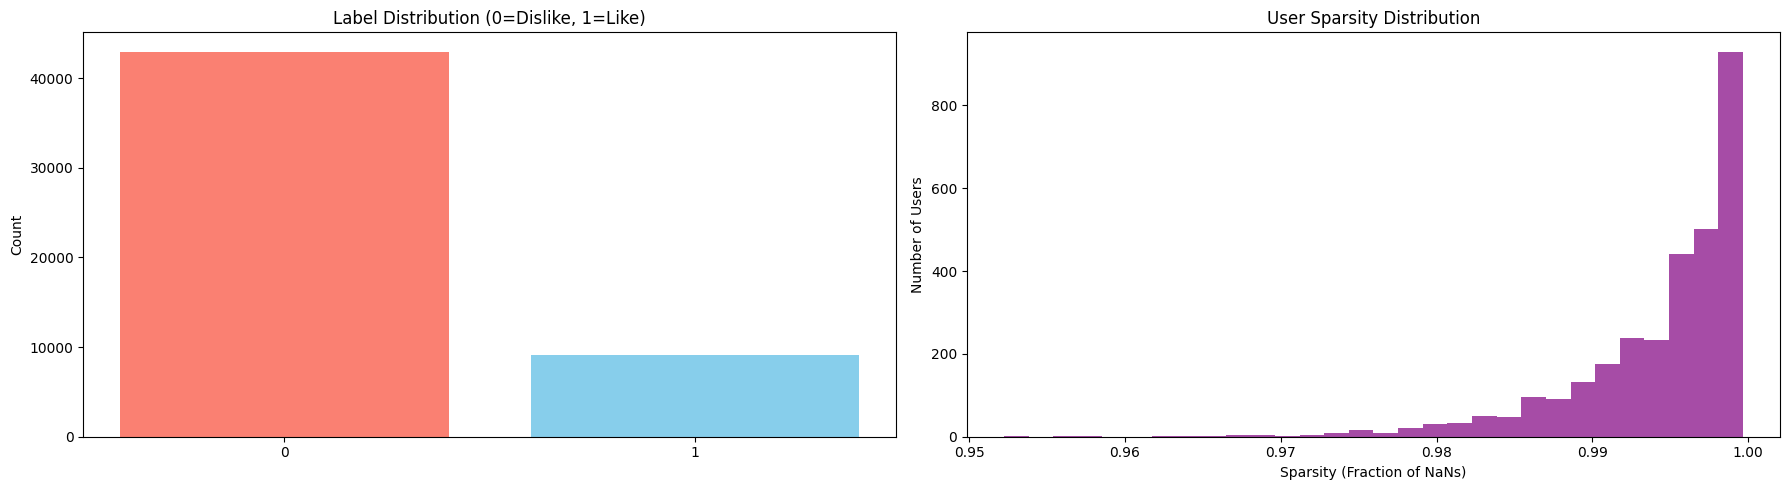

In [82]:
# Sparsity per user
user_sparsity = np.sum(np.isnan(train_data), axis=1) / train_data.shape[1]

# VISUALIZATION: Question 1
fig, ax = plt.subplots(1, 2, figsize=(18, 5))

# Label distribution
ax[0].bar(unique, counts, color=['salmon', 'skyblue'])
ax[0].set_title('Label Distribution (0=Dislike, 1=Like)')
ax[0].set_xticks(unique)
ax[0].set_ylabel('Count')

# User sparsity
ax[1].hist(user_sparsity, bins=30, color='purple', alpha=0.7)
ax[1].set_title('User Sparsity Distribution')
ax[1].set_xlabel('Sparsity (Fraction of NaNs)')
ax[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

- At first glance, we see that the data is very sparse, it seems like people have been on only a couple of dates at most., many NaNs
- There are a lot more dislikes than likes and this creates sparsity as it makes it harder for us to make accurate recomendations.
- It's a lot more common to see rows of users who have a lot of NaNs.

Average likes per user: 16.92
Median likes per user: 12.0


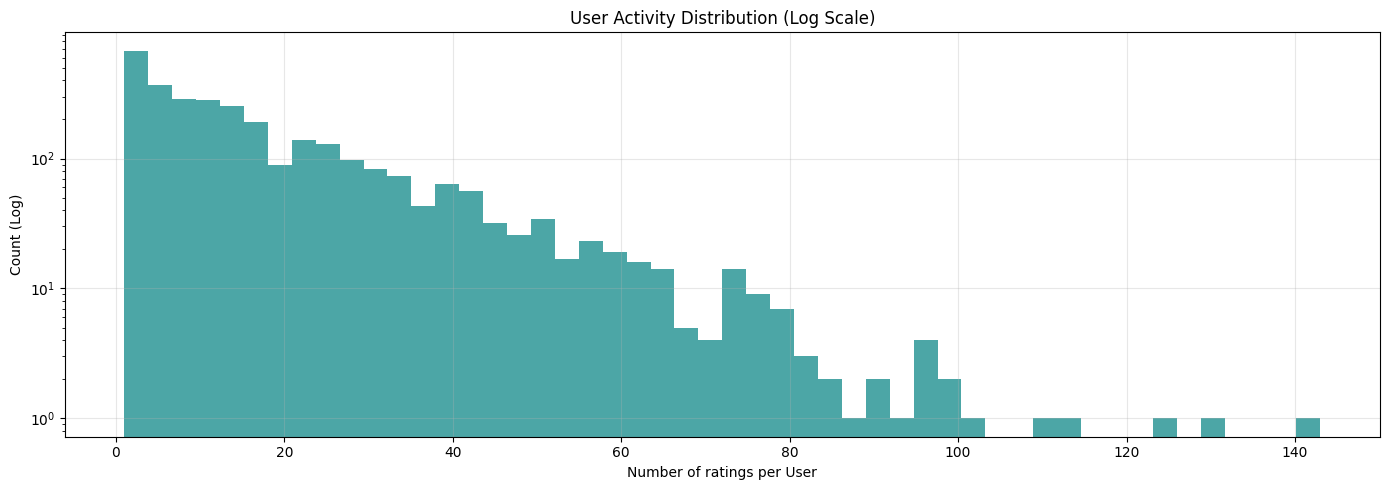

In [83]:
# Activity levels (inverse of sparsity) - How many total ratings users get
user_activity = np.sum(~np.isnan(train_data), axis=1)

print(f"Average likes per user: {np.mean(user_activity):.2f}")
print(f"Median likes per user: {np.median(user_activity)}")

fig, ax = plt.subplots(figsize=(14, 5))

# User Activity
ax.hist(user_activity, bins=50, log=True, color='teal', alpha=0.7)
ax.set_title('User Activity Distribution (Log Scale)')
ax.set_xlabel('Number of ratings per User')
ax.set_ylabel('Count (Log)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Average likes per user: 2.97
Median likes per user: 1.0
Average dislikes per user: 13.94
Median dislikes per user: 8.0


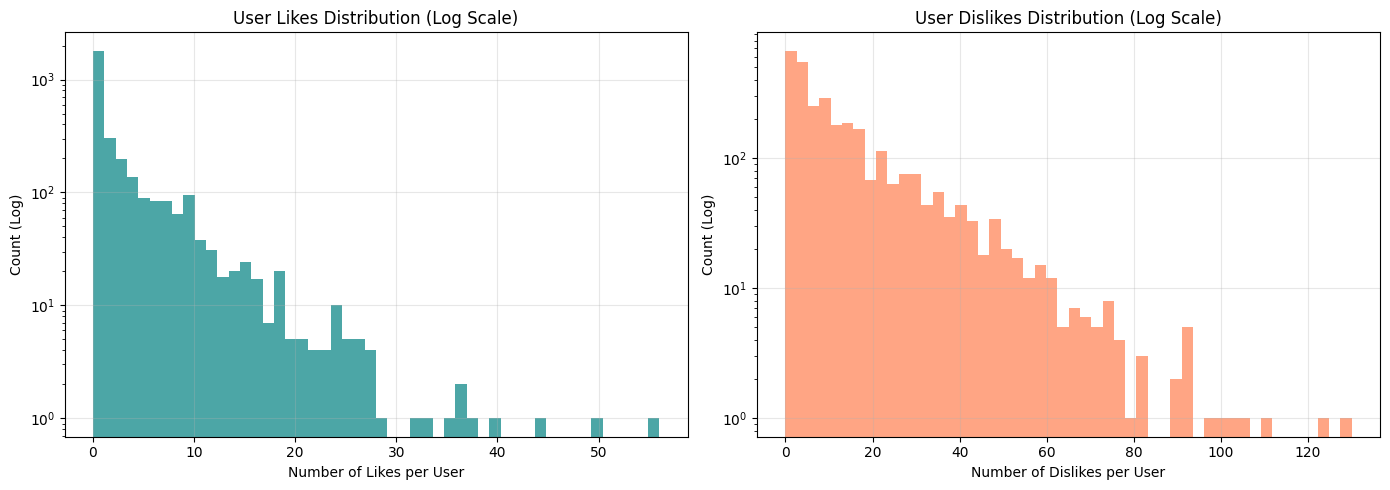

In [84]:
# Activity levels (inverse of sparsity) - How many ratings a user gets by type of rating
user_likes = np.nansum((train_data), axis=1)
user_dislikes = np.sum(train_data == 0, axis=1)

print(f"Average likes per user: {np.mean(user_likes):.2f}")
print(f"Median likes per user: {np.median(user_likes)}")
print(f"Average dislikes per user: {np.mean(user_dislikes):.2f}")
print(f"Median dislikes per user: {np.median(user_dislikes)}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# User Likes
ax[0].hist(user_likes, bins=50, log=True, color='teal', alpha=0.7)
ax[0].set_title('User Likes Distribution (Log Scale)')
ax[0].set_xlabel('Number of Likes per User')
ax[0].set_ylabel('Count (Log)')
ax[0].grid(True, alpha=0.3)

# User Dislikes
ax[1].hist(user_dislikes, bins=50, log=True, color='coral', alpha=0.7)
ax[1].set_title('User Dislikes Distribution (Log Scale)')
ax[1].set_xlabel('Number of Dislikes per User')
ax[1].set_ylabel('Count (Log)')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Here we dont check how many likes users give to users, but how many likes do users get from users.
- From this we see that there are some outliers to the data, where we have very few people with massive numbers of likes. This shows that these could a type of person that everyone likes.
- These could be used to further jump start the system where we give these recomendations that are more likely to be a like and see how users reacct to them.
- On the other hand we have these outliers of peple with an enormous amount of dislikes.

Average likes per user: 17.41
Median likes per user: 11.0


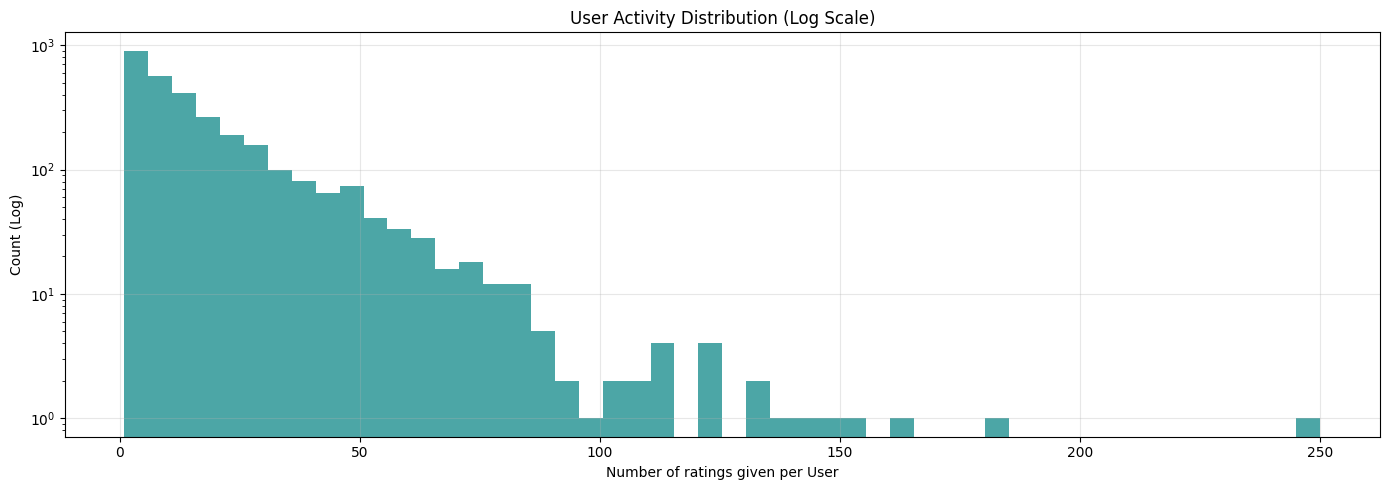

In [85]:
# Activity levels (inverse of sparsity) - How many ratings given per user
user_activity = np.sum(~np.isnan(train_data), axis=0)

print(f"Average likes per user: {np.mean(user_activity):.2f}")
print(f"Median likes per user: {np.median(user_activity)}")

fig, ax = plt.subplots(figsize=(14, 5))

# User Activity
ax.hist(user_activity, bins=50, log=True, color='teal', alpha=0.7)
ax.set_title('User Activity Distribution (Log Scale)')
ax.set_xlabel('Number of ratings given per User')
ax.set_ylabel('Count (Log)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- This is a plot of how many likes and dislikes have been given by a user to other users, as we can see there are some users that are very desparate and are very active while others barely interact.

Average likes given per user: 3.06
Median likes given per user: 1.0
Average dislikes given per user: 14.35
Median dislikes given per user: 9.0


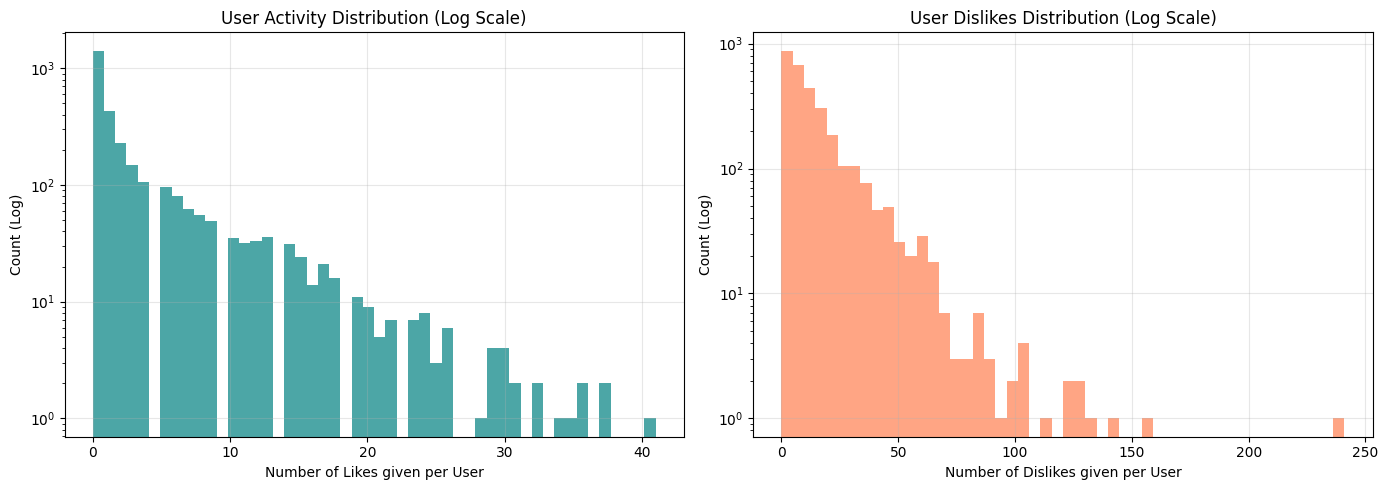

In [86]:
# Activity levels (inverse of sparsity) - How many ratings per user
user_likes = np.nansum((train_data), axis=0)
user_dislikes = np.sum(train_data == 0, axis=0)

print(f"Average likes given per user: {np.mean(user_likes):.2f}")
print(f"Median likes given per user: {np.median(user_likes)}")
print(f"Average dislikes given per user: {np.mean(user_dislikes):.2f}")
print(f"Median dislikes given per user: {np.median(user_dislikes)}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# User Activity
ax[0].hist(user_likes, bins=50, log=True, color='teal', alpha=0.7)
ax[0].set_title('User Activity Distribution (Log Scale)')
ax[0].set_xlabel('Number of Likes given per User')
ax[0].set_ylabel('Count (Log)')
ax[0].grid(True, alpha=0.3)

# User Dislikes
ax[1].hist(user_dislikes, bins=50, log=True, color='coral', alpha=0.7)
ax[1].set_title('User Dislikes Distribution (Log Scale)')
ax[1].set_xlabel('Number of Dislikes given per User')
ax[1].set_ylabel('Count (Log)')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Here we see that users are a lot more reluctant to give dislikes as compared to likes, and there are some users that have given many with many dislikes.

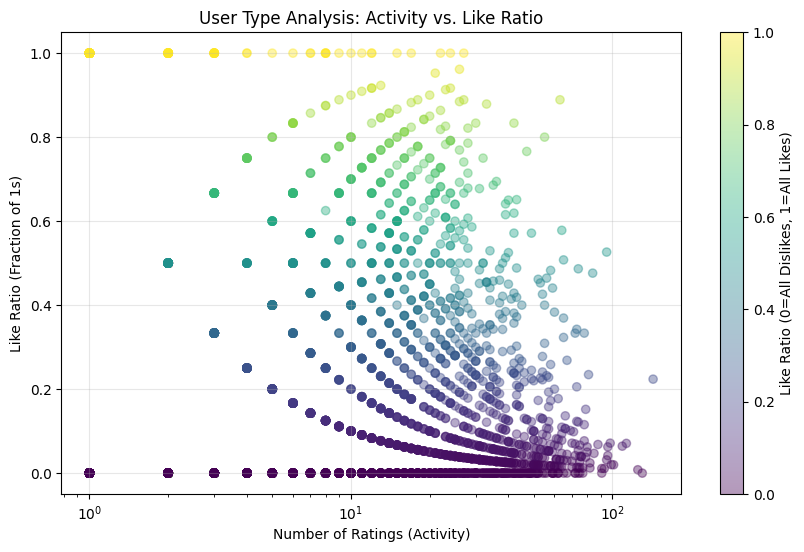

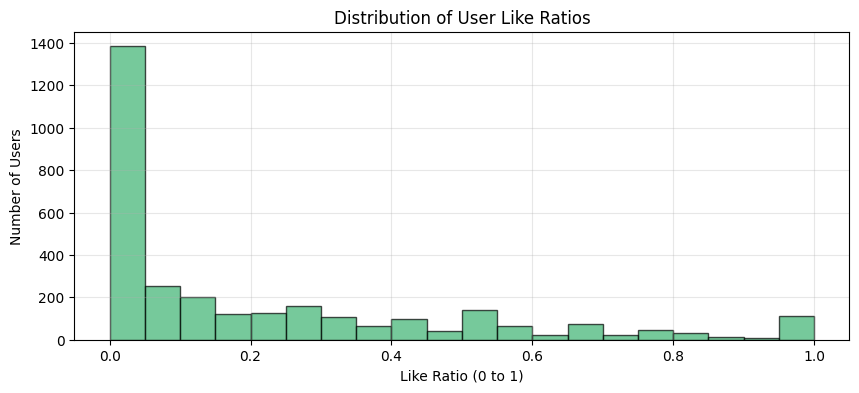

In [87]:
# Calculate like ratio per user (Average rating since 0=dislike, 1=like)
user_means = []
user_counts = []

for row in train_data:
    ratings = row[~np.isnan(row)]
    if len(ratings) > 0:
        user_means.append(np.mean(ratings))
        user_counts.append(len(ratings)) 

user_means = np.array(user_means)
user_counts = np.array(user_counts)

# Scatter plot: Activity vs Preference
# We will use the log scale for the x axis due to skew
plt.figure(figsize=(10, 6))
plt.scatter(user_counts, user_means, alpha=0.4, c=user_means, cmap='viridis')
plt.colorbar(label='Like Ratio (0=All Dislikes, 1=All Likes)')
plt.title('User Type Analysis: Activity vs. Like Ratio')
plt.xlabel('Number of Ratings (Activity)')
plt.ylabel('Like Ratio (Fraction of 1s)')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.show()

# Histogram of Like Ratios
plt.figure(figsize=(10, 4))
plt.hist(user_means, bins=20, color='mediumseagreen', edgecolor='black', alpha=0.7)
plt.title('Distribution of User Like Ratios')
plt.xlabel('Like Ratio (0 to 1)')
plt.ylabel('Number of Users')
plt.grid(True, alpha=0.3)
plt.show()

- From this again we see that most users have a very low like ratio.

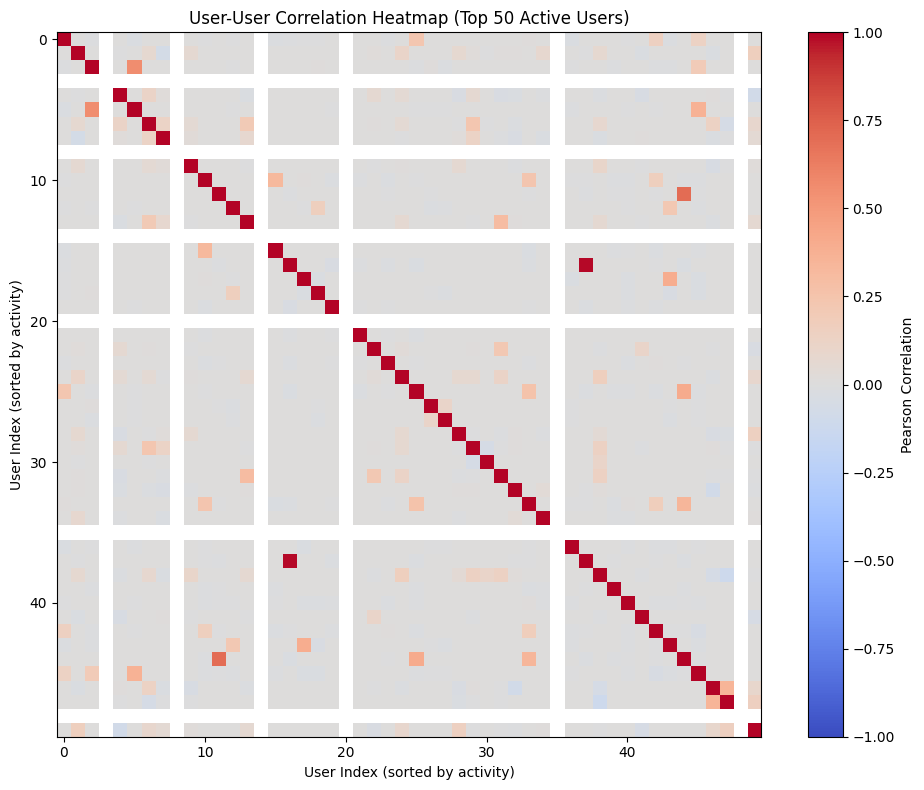

In [88]:
# This helps identify "linear dependence and similar users

# Select Top Active Users
# We'll focus on the top 50 most active users to make the heatmap readable
user_activity_counts = np.sum(~np.isnan(train_data), axis=1)
top_active_users_idx = np.argsort(user_activity_counts)[-50:]
subset_data = train_data[top_active_users_idx]

# Prepare Data for Correlation
# We need to handle NaNs. For this visualization, we'll fill NaNs with the user's mean rating
# This centers the unrated items around the user's average preference
subset_means = np.nanmean(subset_data, axis=1, keepdims=True)
subset_data_filled = np.where(np.isnan(subset_data), subset_means, subset_data)

# Calculate Pearson Correlation Coefficient
# np.corrcoef calculates correlation between rows (users)
correlation_matrix = np.corrcoef(subset_data_filled)

# Plot Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1, interpolation='nearest')

ax.set_title('User-User Correlation Heatmap (Top 50 Active Users)')
ax.set_xlabel('User Index (sorted by activity)')
ax.set_ylabel('User Index (sorted by activity)')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Pearson Correlation')

plt.tight_layout()
plt.show()


- From this we see that there are some users that have similar preferences.

### Answers to Familiarization Questions

1. What properties of the data do you think are important for your pipeline design?

*   Extreme Sparsity: The data is 99.43% sparse. This is a critical property. Standard matrix factorization methods that treat missing values as zeros would be incorrect here. We need methods that explicitly handle missing data (like the NMF with NaN handling we will implement) or methods that work with sets of interactions (like MinHash).

*   Label Imbalance: There are significantly more dislikes (0s) than likes (1s) - a ratio of about 4.7 to 1. This means a naive classifier that always predicts 0 would have high accuracy (~82%) but would be useless for recommendations. Our evaluation metric needs to account for this (e.g., precision/recall for the positive class, or ranking metrics).

*   Linear Dependence / Similarity: The correlation heatmap of the most active users shows distinct blocks of high correlation (red) and anti-correlation (blue). This indicates that users are not independent; there are groups of users with very similar (and very dissimilar) taste profiles. This "linear dependence" is exactly what collaborative filtering exploits.


2. What are some sources of sparsity in the data?

*   User Behavior: Users typically only rate a tiny fraction of available items. The median user rated only 11 items.

*   Item Visibility/Popularity: Most items are rated by very few users (Median 12 ratings). This long tail of unpopular items contributes significantly to sparsity.

*   Systematic Missingness: Users might only rate items they have strong feelings about (either really liked or really disliked), leaving "average" items unrated.


3. Do you see different types of people?

*   Activity Levels: Yes, the activity distribution is highly skewed (long-tailed). There are a few power users with many ratings, but the vast majority have very few.

*   Preferences (Like Ratio): The scatter plot and histogram reveal distinct user behaviors:
    *   Critics: A large cluster of users have a low like ratio (near 0.0), meaning they dislike most things they rate.
    *   Enthusiasts: A smaller group has a high like ratio (near 1.0).
    *   Balanced: Some users fall in the middle.

*   Similarity Clusters: The correlation heatmap confirms the existence of types of people. The visible blocks along the diagonal (after sorting) or off-diagonal suggest clusters of users who tend to agree with each other.


## WebLab solutions

In [ ]:
# Solution: NMF routine (for unit test on weblab)

def nmf(X, n_components: int, max_iter: int=1000, tol: float=1e-3):
    """
    Decomposes the original sparse matrix X into two matrices W and H.
    """

    # [Your solution]

    return W, H

In [ ]:
# Solution: Min-hashing routine (for unit test on weblab)

def compute_signature(hashes: list[HashFunction], ids: list[set[int]]):
    """
    This function will calculate the MinHash signature matrix from our sets of ids
    using the list of hash functions (hashes)
    :param hashes: The list of hash functions of arbitrary length
    :param ids: The list of sets of ids
    :return: The MinHash signature matrix for the given sets of ids
    """

    # [Your solution]

    return result

## NMF-based recommender system

In [ ]:
# Step 1: NMF routine which can handle NaNs! (for the 'real data' NMF recommender system task)

def nmf_nan(X, n_components: int, max_iter: int=1000, tol: float=1e-3):
    """
    Computes NMF of matrix X which includes 'unknown' NaN values.
    """

    # [Your solution]

    return W, H, reconstruction_error

In [ ]:
# Step 2: Fit train data

np.random.seed(5)
list_components = np.array([5,10,20,50,100])

# Compute nmf_nan() using the n_components in list_components, and following the instructions in the assignment pdf.


# Plot the final reconstruction error as a function of n_components

In [ ]:
# Step 3: Get training accuracies

# Declare some list of thresholds to try: list_thr...

for c in range(len(list_components)):

    for t in range(len(list_thr)):

        # Compute training accuracy

In [ ]:
# Step 4: Get validation accuracies
# This is where we fit the n_components and the threshold

for c in range(len(list_components)):

    for t in range(len(list_thr)):

        # Compute validation accuracy

In [ ]:
# Step 5: Get the final test accuracy
# We use the n_components and the threshold we fit on the validation set

# Compute test accuracy

print(f"Test accuracy: {test_accuracy:g}%, thr: {thr:g}, n_components: {comp}")

## Distance-based recommender system

In [ ]:
# Use min-hashing on the rows and find the nearest neighbors using Jaccard distance

# Use min-hashing on the columns and find the nearest neighbors using Jaccard distance

In [ ]:
# Aggregate the user-user and item-item nearest neighbor information to estimate recommendations



In [ ]:
# Cross-validate on the validation data: number of hash functions and number of neighbors
# (As we did for NMF above, for the n_components and the threshold.)

In [ ]:
# Report recommendation accuracy on the independent test data